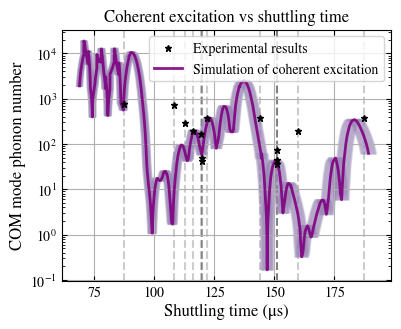

In [1]:
import numpy as np
import matplotlib
from pathlib import Path
import matplotlib.pyplot as plt

matplotlib.rcParams.update(
        {"font.family": "STIXGeneral",
         "xtick.labelsize": 12,
         "xtick.direction": "in",
         "xtick.major.pad": 3,
         "xtick.top": True,
         "ytick.labelsize": 12,
         "ytick.direction": "in",
         "ytick.right": True,
         "axes.labelsize": 12,
         "axes.labelpad": 3,
         "axes.grid": True
    }
)

out_dir = Path("./outputs")

t_avg = np.load(out_dir / "avg_curve_time.npy")        # shape (N,)
p_avg = np.load(out_dir / "avg_curve_phonon.npy")      # shape (N,)
exp_points = np.load(out_dir / "experimental_points.npy")

half_column_width_inches = 4.25
aspect_ratio = 1.3

# ------------------------------------------------------------------
# 1. Build many scaled-time curves (20 samples across ±3 σ)
scale_delta = 3.03 / 179.96
n_samples = 50
scales = np.linspace(1 - scale_delta, 1 + scale_delta, n_samples)

# t_scaled has shape (n_samples, N)
t_scaled = scales[:, None] * t_avg[None, :]

# 2. Envelope in time for every phonon value
t_min = t_scaled.min(axis=0)
t_max = t_scaled.max(axis=0)

# 3. Sort by phonon number so fill_betweenx doesn’t self-intersect
order = np.argsort(p_avg)
p_sorted   = p_avg[order]
t_min_sort = t_min[order]
t_max_sort = t_max[order]

# ------------------------------------------------------------------
plt.figure(figsize=(half_column_width_inches,
                    half_column_width_inches / aspect_ratio))

# # Shade the full envelope
# plt.fill_betweenx(p_sorted, t_min_sort, t_max_sort,
#                   color="#9c89b8", alpha=0.45,
#                   label="Trap frequency ±3σ", zorder=1)

# (Optional) show the individual realisations very faintly
for ts in t_scaled:
    plt.plot(ts, p_avg, color="#9c89b8", alpha=0.15, zorder=1)

# Experimental points
plt.plot(exp_points[:, 0], exp_points[:, 1], "k*", markersize=5,
         label="Experimental results", zorder=3)

# Central (mean) curve
plt.plot(t_avg, p_avg, "-", lw=2, color="purple", alpha=0.9,
         label="Simulation of coherent excitation", zorder=2)

# Vertical guide lines at experimental times (optional)
for tx in exp_points[:, 0]:
    plt.axvline(tx, color="black", linestyle="--", alpha=0.2, zorder=0)

plt.xlabel("Shuttling time (μs)", fontsize=12)
plt.ylabel("COM mode phonon number", fontsize=12)
plt.title("Coherent excitation vs shuttling time", fontsize=12)
plt.yscale("log")
plt.grid(True)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.legend()

plt.savefig(out_dir / "Phonon_number_vs_shuttling_time_from_cache.pdf",
            format="pdf", bbox_inches="tight")
plt.show()
